#Objetivo da Atividade

Neste notebook, vamos praticar **visualização de dados com a biblioteca Seaborn** utilizando um dataset real sobre **seguros de saúde**.

O objetivo é explorar visualmente como variáveis como:

- `age` (idade),  
- `bmi` (índice de massa corporal),  
- `smoker` (tabagismo),  
- `sex` (sexo),  
- `children` (número de filhos) e  
- `region` (região de residência)  

influenciam o **custo do seguro de saúde (`charges`)**.

---

Ao final da atividade, você será capaz de:

- Utilizar diferentes tipos de gráficos do Seaborn;  
- Identificar padrões, correlações e possíveis outliers nos dados;  
- Gerar insights visuais que ajudem a entender o comportamento do custo do seguro com base nas demais variáveis.

Vamos explorar os dados com Seaborn!


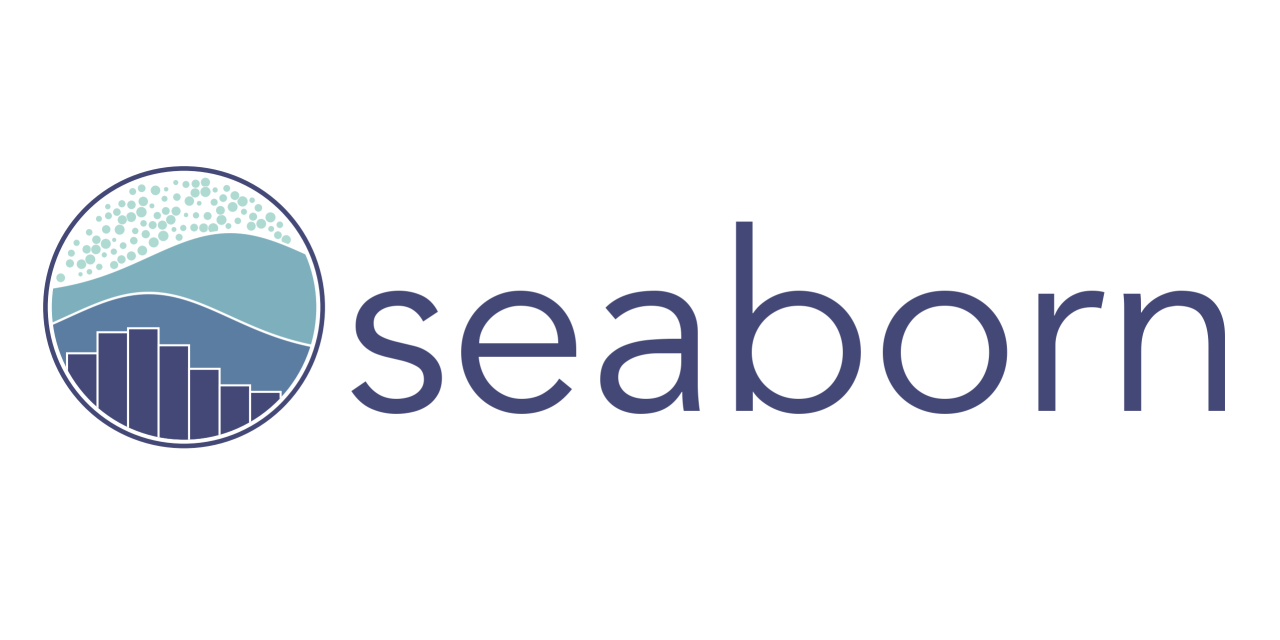

---



## **1. Importação das bibliotecas e carregamento dos dados traduzidos.**

In [1]:
# Importando as bibliotecas necessárias
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import gdown

In [2]:
# Baixando um dataset 'insurance.csv' no formato CSV
#!gdown '1JooBu9HnLOsQApoAUAJ3oy6N9lpSG3Et'

In [3]:
# Utilize o pandas para ler o arquivo 'insurance.csv' e inspecionar os primeiros registros
df = pd.read_csv('insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Renomeie as colunas do dataframe para nomes em português, facilitando a leitura e análise dos dados. Em seguida, inspecione os primeiros registros
#['idade', 'sexo', 'imc', 'filhos', 'fumante', 'regiao', 'despesas']


# Supondo que você já tenha um DataFrame chamado df
# Renomeando as colunas para português
df.rename(columns={
    'age': 'idade',
    'sex': 'sexo',
    'bmi': 'imc',
    'children': 'filhos',
    'smoker': 'fumante',
    'region': 'regiao',
    'charges': 'despesas'
}, inplace=True)

# Inspecionando os primeiros registros
print(df.head())

   idade    sexo     imc  filhos fumante     regiao     despesas
0     19  female  27.900       0     yes  southwest  16884.92400
1     18    male  33.770       1      no  southeast   1725.55230
2     28    male  33.000       3      no  southeast   4449.46200
3     33    male  22.705       0      no  northwest  21984.47061
4     32    male  28.880       0      no  northwest   3866.85520


# **2. Gráficos Estatísticos Prontos**



**2.1 Gráfico de dispersão**

As variáveis que podem ser usadas para plotar um gráfico de dispersão (scatterplot) são aquelas do tipo quantitativo (numéricas), pois esse tipo de gráfico é utilizado para explorar a relação entre duas variáveis numéricas. Por exemplo, ele pode ser usado para investigar se há correlação entre a idade e o índice de massa corporal, ou entre o número de filhos e os custos médicos.
Variáveis categóricas, por sua vez, não são apropriadas para compor os eixos de um gráfico de dispersão, mas podem ser utilizadas como elementos visuais complementares, como cor ou estilo dos pontos, ajudando a distinguir as observações por categoria.

In [5]:
# Crie um dicionário para traduzir do inglês para o português os valores da coluna 'fumante'.
# Em seguida aplique essa substituição na coluna 'fumante' e inspecione os primeiros registros

# Dicionário para traduzir os valores
traducao_fumante = {
    'yes': 'sim',
    'no': 'não'
}

# Aplicar a tradução na coluna 'fumante'
df['fumante'] = df['fumante'].replace(traducao_fumante)

# Inspecionar os primeiros registros
print(df.head())


   idade    sexo     imc  filhos fumante     regiao     despesas
0     19  female  27.900       0     sim  southwest  16884.92400
1     18    male  33.770       1     não  southeast   1725.55230
2     28    male  33.000       3     não  southeast   4449.46200
3     33    male  22.705       0     não  northwest  21984.47061
4     32    male  28.880       0     não  northwest   3866.85520


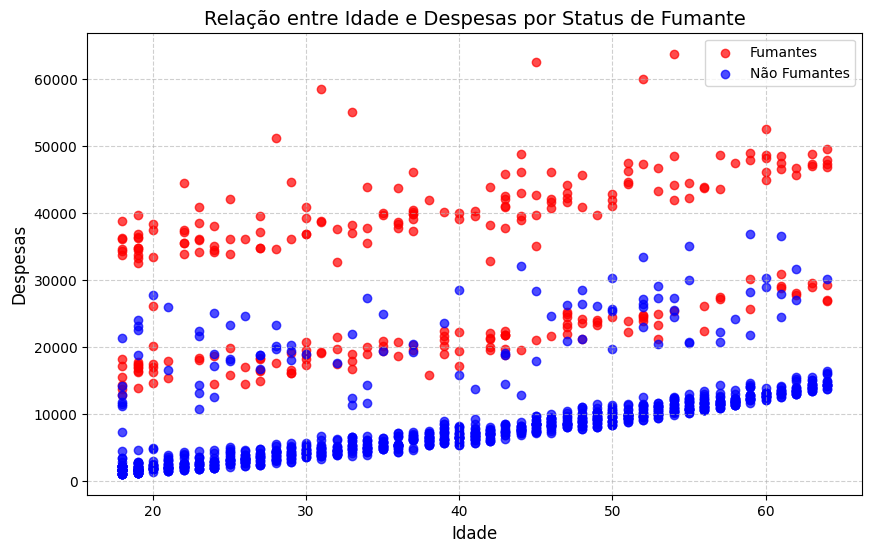

In [6]:
# Em seguida, crie um gráfico de dispersão entre idade (eixo x) e despesas (eixo y), diferenciando os fumantes dos não fumantes


# Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))

# Filtrar os dados para fumantes e não fumantes
fumantes = df[df['fumante'] == 'sim']
nao_fumantes = df[df['fumante'] == 'não']

# Plotar os dados
plt.scatter(fumantes['idade'], fumantes['despesas'], color='red', label='Fumantes', alpha=0.7)
plt.scatter(nao_fumantes['idade'], nao_fumantes['despesas'], color='blue', label='Não Fumantes', alpha=0.7)

# Adicionar título e rótulos
plt.title('Relação entre Idade e Despesas por Status de Fumante', fontsize=14)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Despesas', fontsize=12)

# Adicionar legenda
plt.legend()

# Mostrar o gráfico
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

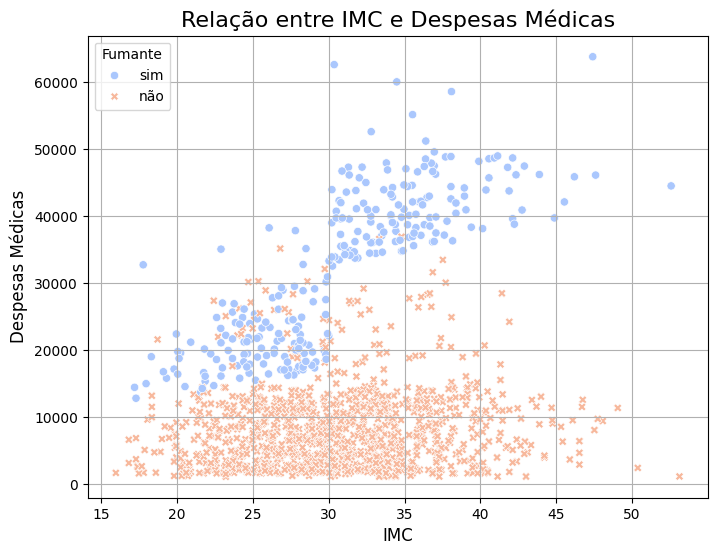

In [7]:
# Crie um gráfico de dispersão para analisar a relação entre IMC (eixo x) e despesas médicas (eixo y)
# Criando o gráfico de dispersão
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='imc', y='despesas', hue='fumante', style='fumante', palette='coolwarm')

# Adicionando título e rótulos
plt.title('Relação entre IMC e Despesas Médicas', fontsize=16)
plt.xlabel('IMC', fontsize=12)
plt.ylabel('Despesas Médicas', fontsize=12)
plt.legend(title='Fumante', loc='upper left')
plt.grid(True)

# Exibindo o gráfico
plt.show()

## **2.2 Histograma**

Um histograma é um gráfico que mostra a distribuição de um conjunto de dados, visualizando a frequência ou densidade de ocorrências em intervalos específicos, chamados de "bins" ou "classes". O eixo horizontal representa esses intervalos, e o eixo vertical mostra a frequência dos dados em cada classe.

Para construir um histograma, os dados são divididos em intervalos contíguos e de tamanhos iguais. Em seguida, conta-se a frequência de observações em cada intervalo. No gráfico, cada intervalo é representado por uma barra cuja altura reflete essa frequência.

Muitas vezes é possível visualizar a função de densidade de probabilidade dos dados através do KDE (do inglês Kernel Density Estimation),  uma técnica de suavização que estima a função de densidade de probabilidade de uma variável contínua, construindo uma curva por cima do gráfico

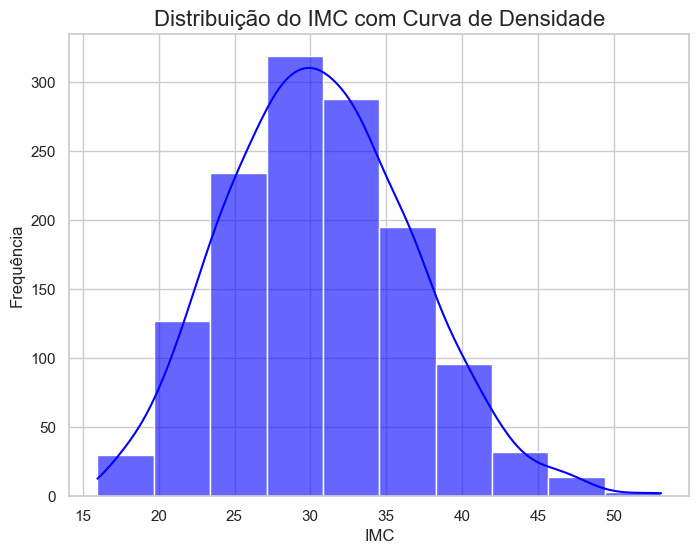

In [8]:
# Crie um histograma da variável IMC e adicione a curva de densidade (KDE) para visualizar a distribuição dos dados


# Configurar o estilo do gráfico
sns.set(style="whitegrid")

# Criar o histograma com a curva de densidade (KDE)
plt.figure(figsize=(8, 6))
sns.histplot(df["imc"], kde=True, bins=10, color="blue", alpha=0.6)

# Adicionar título e rótulos
plt.title("Distribuição do IMC com Curva de Densidade", fontsize=16)
plt.xlabel("IMC", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

# Mostrar o gráfico
plt.show()


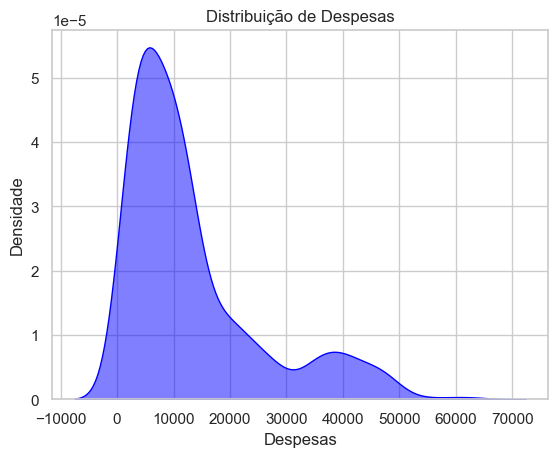

In [9]:
# Plote apenas a curva de densidade (KDE) da variável despesas para analisar sua distribuição
# Plotar a curva de densidade (KDE)
sns.kdeplot(data=df, x='despesas', fill=True, color='blue', alpha=0.5)

# Adicionar título e rótulos aos eixos
plt.title('Distribuição de Despesas')
plt.xlabel('Despesas')
plt.ylabel('Densidade')

# Exibir o gráfico
plt.show()

# **2.3 BoxPlot**

Um boxplot, ou diagrama de caixa, é uma representação gráfica que resume a distribuição de um conjunto de dados através de cinco estatísticas principais: mínimo, primeiro quartil, mediana, terceiro quartil e máximo.

Como o gráfico abaixo representa as despesas por região (Sudoeste, Sudeste, Noroeste, Nordeste), a linha horizontal no meio de cada caixa representa a **mediana** das despesas em cada região. Isso mostra o valor central das despesas, onde metade dos valores está acima e metade abaixo. Com isso, a região Sudeste parece ter uma mediana ligeiramente mais alta que as outras regiões.

As extremidades das caixas representam o primeiro (**Q1**) e o terceiro quartil (**Q3**), mostrando a dispersão das despesas entre os 25% e os 75% dos dados.
A região Sudeste tem uma caixa maior, sugerindo uma maior **dispersão** das despesas nessa região em comparação com as outras.

Já as linhas que se estendem a partir das caixas (os "bigodes") mostram a **amplitude das despesas**, excluindo os outliers. Elas indicam o **intervalo interquartil** e geralmente se estendem até 1,5 vezes o intervalo interquartil (IQR=Q3-Q1). Nesse caso, as regiões Noroeste e Sudoeste têm bigodes que se estendem à valores menores em comparação com as outras regiões.

Os círculos acima dos bigodes são os outliers, que são valores de despesas significativamente maiores que o restante dos dados. Esses outliers indicam casos de despesas muito altas. Todas as regiões apresentam vários outliers, com a região sudeste exibindo os maiores outliers.


In [10]:
# Crie um dicionário para traduzir os nomes das regiões do inglês para o português.
dicionario_regiao = {'southeast': 'sudeste',
                     'southwest': 'sudoeste',
                     'northeast': 'nordeste',
                     'northwest': 'noroeste'}


# Em seguida aplique essa substituição na coluna 'regiao' e inspecione os primeiros registros
df['regiao'] = df['regiao'].replace(dicionario_regiao)
df.head()


,idade,sexo,imc,filhos,fumante,regiao,despesas
0,19,female,27.900,0,sim,sudoeste,16884.92400
1,18,male,33.770,1,não,sudeste,1725.55230
2,28,male,33.000,3,não,sudeste,4449.46200
3,33,male,22.705,0,não,noroeste,21984.47061
4,32,male,28.880,0,não,noroeste,3866.85520


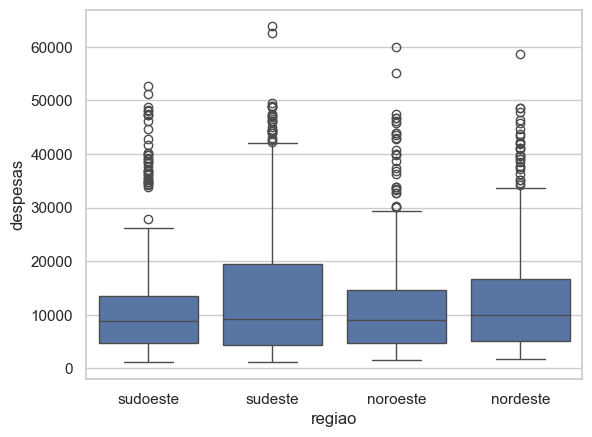

In [11]:
# Crie um boxplot para comparar a distribuição das despesas médicas entre as diferentes regiões
sns.boxplot(x='regiao', y='despesas', data=df)
plt.show()

# **2.4 Gráfico de Barras**

Um gráfico de barras é uma representação visual que compara valores entre diferentes **categorias** usando barras retangulares, onde o comprimento de cada barra é proporcional aos valores que as variáveis **categóricas** assumem.

A linha no topo das colunas nesse gráfico de barras representa o intervalo de confiança ou o erro padrão da média (também conhecido como barras de erro). Essas linhas indicam a incerteza associada à estimativa da média das despesas para os grupos de fumantes ("sim") e não fumantes ("não").

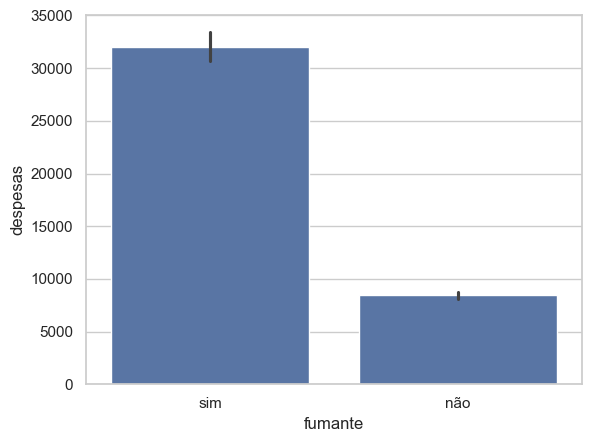

In [12]:
# Crie um gráfico de barras para comparar a média das despesas médicas entre fumantes e não fumantes
sns.barplot(x='fumante', y='despesas', data=df)
plt.show()

## **3. DEMAIS GRÁFICOS**

**3.1 Comparação de Grupos**

O Seaborn também oferece o catplot, que é utilizado para visualizar a relação entre uma variável categórica (neste caso, o status de fumante) e uma variável contínua (neste caso, as despesas).

Para os fumantes ("sim"), as despesas parecem variar bastante, com muitos pontos acima de 20.000 até mais de 60.000.
Para os não fumantes ("não"), as despesas se concentram em valores mais baixos, com poucos pontos acima de 20.000.

Assim, pode-se perceber que os fumantes geralmente têm despesas mais altas, possivelmente relacionadas a maiores custos médicos e que os não fumantes tendem a ter despesas mais baixas e concentradas em um intervalo mais estreito.
Logo, o gráfico indica que ser fumante está associado a maiores despesas.

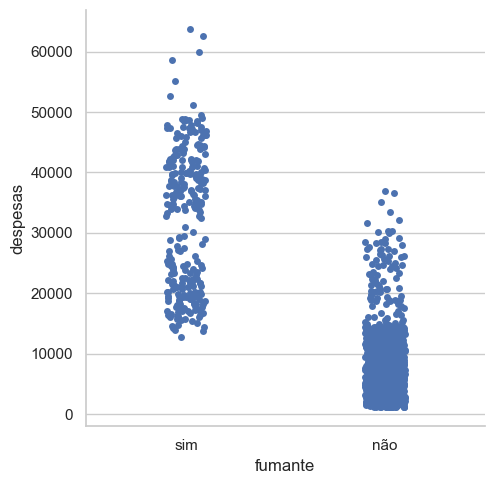

In [13]:
# Utilize um catplot do tipo 'strip' para visualizar a distribuição das despesas médicas de acordo com o status de fumante
sns.catplot(x='fumante', y='despesas', data=df, kind='strip')
plt.show()

**3.2 Plotagem de relações**

O gráfico pairplot exibe a relação entre várias variáveis numéricas simultaneamente, criando uma matriz de gráficos de dispersão e histogramas. Ele nos ajuda a entender, através de uma visão geral, como diferentes variáveis se correlacionam umas com as outras.

Ao longo da diagonal, temos os histogramas que mostram a distribuição de cada variável, como "idade", "IMC", "número de filhos" e "despesas".
Por exemplo, o histograma de "idade" mostra que a maioria dos indivíduos está na faixa dos 20 a 60 anos. O "IMC" tem uma distribuição aproximadamente normal, e a maioria das pessoas tem 0 a 3 filhos.

Cada gráfico fora da diagonal representa a relação entre duas variáveis específicas, de modo que:

*   Idade x Despesas: Mostra uma tendência crescente, ou seja, à medida que a idade aumenta, as despesas tendem a aumentar também.
*   IMC x Despesas: Não parece haver uma relação clara, mas podemos observar uma maior variabilidade nas despesas para pessoas com IMC entre 20 e 40.
*   Filhos x Despesas: Não há uma relação clara. As despesas não parecem variar muito com o número de filhos.
*   Idade x IMC: Não parece haver uma correlação significativa.
Observações principais:

Em suma, a relação mais visível é entre "idade" e "despesas", sugerindo que as despesas aumentam com a idade. Além disso, outras variáveis como "IMC" e "filhos" não apresentam correlações tão evidentes com as despesas.


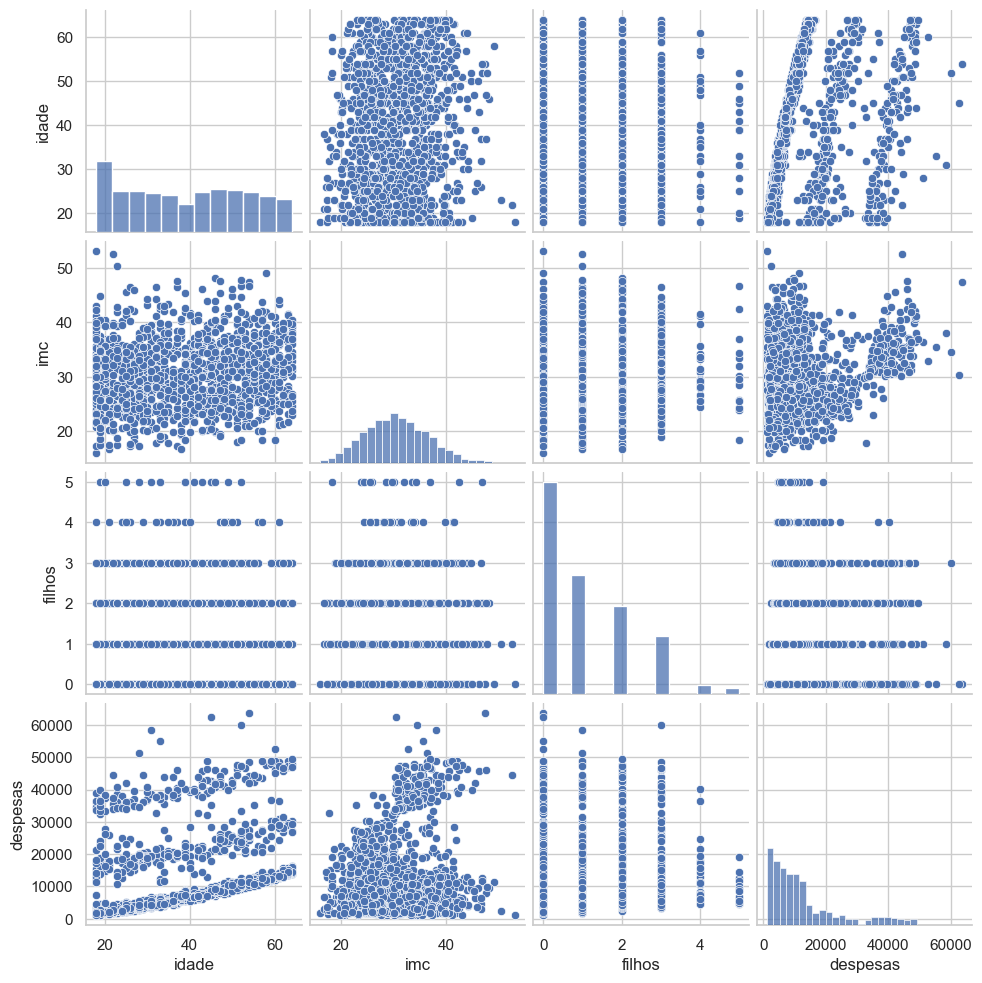

In [14]:
# Utilize um pairplot para explorar visualmente as relações entre todas as variáveis numéricas do conjunto de dados
sns.pairplot(df)
plt.show()

**3.3 Mapa de Calor**

O mapa de calor da matriz de correlação visualiza a correlação entre variáveis numéricas, sendo uma boa ferramenta para visualizar rapidamente quais variáveis têm maior influência umas sobre as outras. As cores indicam o grau de correlação entre as variáveis, com valores variando de -1 (correlação negativa perfeita) a 1 (correlação positiva perfeita). Sendo que **Cores Vermelhas e Azul Claras** representam correlações positivas mais fortes (Quanto mais próxima de 1, mais forte a correlação positiva); e **Cores Azul Escuras** representam correlações próximas de 0, o que indica pouca ou nenhuma correlação.

Assim, pode-se perceber no gráfico abaixo as seguintes correlações:

*   Idade x Despesas (0.3): Há uma correlação positiva moderada entre idade e despesas. Isso indica que pessoas mais velhas tendem a ter despesas maiores.
*   IMC x Despesas (0.2): Existe uma correlação positiva fraca entre IMC e despesas. Pessoas com maior IMC tendem a ter despesas ligeiramente maiores.
*   Filhos x Despesas (0.068): A correlação entre o número de filhos e despesas é muito fraca, sugerindo que o número de filhos não tem um grande impacto nas despesas.
*   Idade x IMC (0.11): A correlação entre idade e IMC é fraca, o que indica que o aumento da idade não está fortemente relacionado ao aumento do IMC.

  Logo, a idade parece ter a maior correlação com as despesas, embora nenhuma correlação seja extremamente forte.

             idade       imc    filhos  despesas
idade     1.000000  0.109272  0.042469  0.299008
imc       0.109272  1.000000  0.012759  0.198341
filhos    0.042469  0.012759  1.000000  0.067998
despesas  0.299008  0.198341  0.067998  1.000000


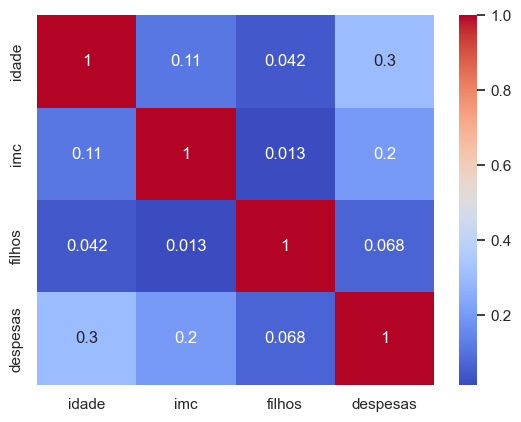

In [15]:
# Selecione apenas as colunas numéricas do dataframe ('float64', 'int64'), pois a correlação só pode ser calculada entre variáveis quantitativas.
df_numeric = df.select_dtypes(include=['float64', 'int64'])
#print(df_numeric)


# Em seguida, crie uma matriz de correlação para analisar como essas variáveis se relacionam entre si — por exemplo, se aumentos em uma variável tendem a acompanhar aumentos ou quedas em outra.
correlation_matrix = df_numeric.corr()
print(correlation_matrix)
# Por fim, utilize um mapa de calor (heatmap) para visualizar essa matriz de forma mais intuitiva, destacando as correlações mais fortes e mais fracas entre as variáveis.
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

**3.4 Plotagem de dados temporais**

A plotagem de dados temporais no Seaborn é uma ferramenta útil para visualizar como uma variável contínua varia ao longo do tempo, oferecendo diferentes funções para plotar séries temporais, tendo como as mais comuns: lineplot() e relplot().

Como não temos uma série temporal na nossa série de dados, o gráfico abaixo utilizou a idade no eixo X, somente para exemplificar como funciona o referido gráfico. Contudo, em uma plotagem de dados temporais, o eixo X geralmente representa o tempo (podendo estar em diferentes escalas, como dias, meses, anos, horas, etc.), com valores dispostos de forma cronológica. Além disso, o eixo Y exibe os valores da variável que está sendo estudada ao longo do tempo.

Assim, o gráfico abaixo mostra a relação entre a idade e as despesas ao longo da vida, de modo que:


*   Eixo X (idade): Representa a idade das pessoas, variando de 20 a 60 anos.
*   Eixo Y (despesas): Representa as despesas, com valores entre 0 e 30.000 (provavelmente em uma moeda específica, como reais ou dólares).
*   Linha azul: Mostra a média das despesas para cada faixa etária. A linha parece ter uma tendência crescente, indicando que, em geral, as despesas aumentam com a idade.
*   Área sombreada: Representa a variabilidade ou incerteza nas despesas para cada faixa etária. Uma área mais ampla indica maior variação nas despesas para aquela idade.


Logo, o gráfico sugere que as despesas tendem a aumentar com a idade, mas há bastante variação nos valores em torno da média, especialmente em idades mais avançadas.

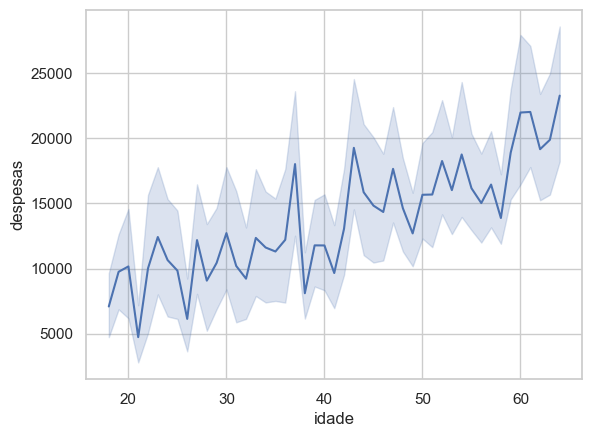

In [16]:
# Crie um gráfico de linha para analisar como as despesas médicas variam de acordo com a idade.
sns.lineplot(x='idade', y='despesas', data=df)
plt.show()
# Embora o conjunto de dados não tenha uma variável temporal real (como data ou ano), a idade pode ser usada como um eixo ordenado para observar tendências ao longo da vida.



**3.5 Grid de Gráficos (Facet Grids)**


Grids de gráficos no Seaborn referem-se a uma maneira eficiente de visualizar múltiplos gráficos em uma única figura, organizados em uma grade (grid). Eles são particularmente úteis quando você quer comparar a distribuição de dados ou relações entre variáveis para diferentes subgrupos. No Seaborn, as principais funções usadas para criar grids de gráficos são FacetGrid, PairGrid, JointGrid.
Abaixo temos um FacetGrid que mostra a relação de despesas e idade em todas as regiões da série de dados, classificando se os pontos estão relacionados a fumantes ou não fumantes

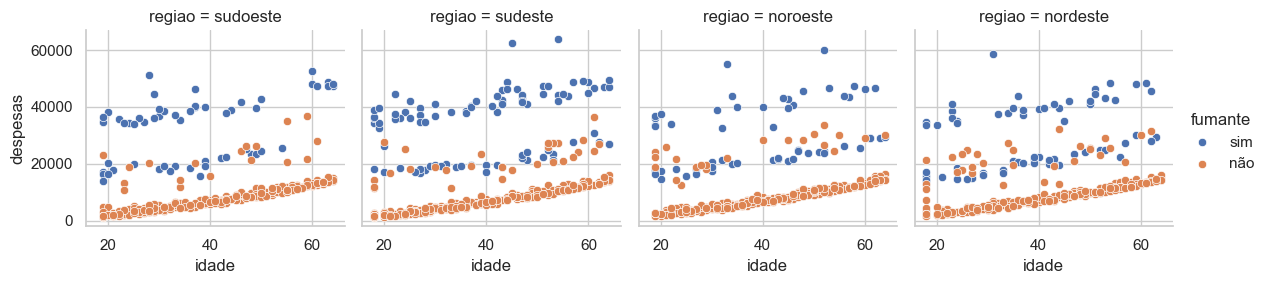

In [17]:
# Utilize um FacetGrid para criar múltiplos gráficos de dispersão, permitindo comparar visualmente as despesas médicas entre fumantes e não fumantes em cada região.
g = sns.FacetGrid(df, col='regiao', hue='fumante')
g.map(sns.scatterplot, 'idade', 'despesas')
g.add_legend()
plt.show()
# Esse tipo de visualização facilita a análise segmentada dos dados, mostrando como a relação entre idade e despesas varia de acordo com a região e o status de fumante.



## **4. Trabalhando com Variáveis Categóricas**

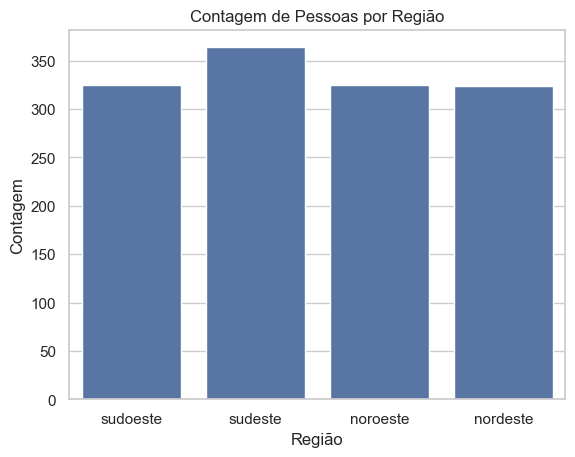

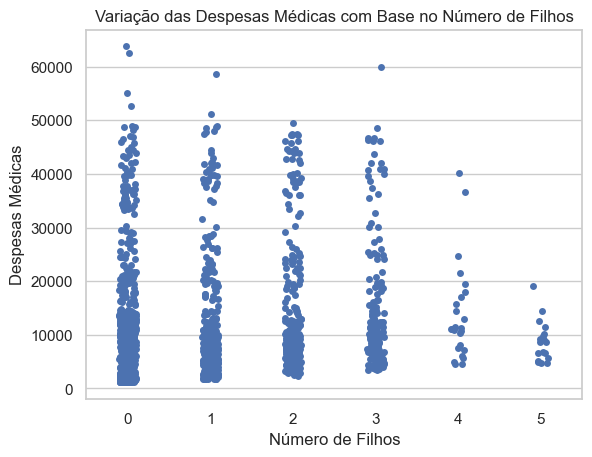

In [28]:
# Crie um gráfico de barras (countplot) para visualizar a quantidade de pessoas em cada região.
sns.countplot(x='regiao', data=df)
plt.title('Contagem de Pessoas por Região')
plt.xlabel('Região')
plt.ylabel('Contagem')
plt.show()

# Esse tipo de gráfico é útil para entender a distribuição dos dados categóricos no conjunto.

# Em seguida, utilize um stripplot para analisar a variação das despesas médicas com base no número de filhos.
sns.stripplot(x='filhos', y='despesas', data=df, jitter=True)
plt.title('Variação das Despesas Médicas com Base no Número de Filhos')
plt.xlabel('Número de Filhos')
plt.ylabel('Despesas Médicas')
plt.show()

# O stripplot permite visualizar a dispersão dos valores individuais, ajudando a identificar padrões ou concentrações específicas para cada quantidade de filhos.


## **5. Estilos e Paletas de Cores**

O Seaborn oferece uma série de estilos predefinidos que podem ser aplicados para mudar a aparência dos gráficos. A função sns.set_style() permite alterar o estilo dos gráficos. Aqui estão os estilos que você pode usar:

"white": Um estilo simples e limpo, sem grades;
"dark": Um estilo simples com um fundo escuro, sem grades;
"whitegrid": Similar ao "white", mas com grades leves;
"darkgrid": Similar ao "dark", mas com grades claras. Este é o estilo padrão do Seaborn;
"ticks": Um estilo com marcadores de eixos proeminentes e um visual mais estruturado

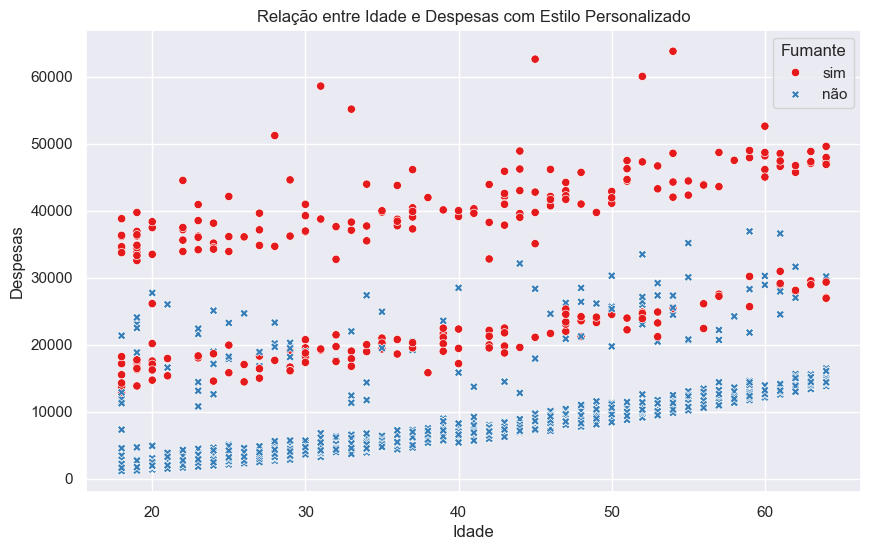

In [29]:
# Defina um estilo visual para os gráficos utilizando o Seaborn (ex: "ticks", "darkgrid", "whitegrid", etc.).
sns.set(style="darkgrid")

# Em seguida, crie um gráfico de dispersão para observar a relação entre idade e despesas, agora com o novo estilo aplicado.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='idade', y='despesas', hue='fumante', style='fumante', palette='Set1')
plt.title('Relação entre Idade e Despesas com Estilo Personalizado')
plt.xlabel('Idade')
plt.ylabel('Despesas')
plt.legend(title='Fumante')
plt.show()

# A personalização do estilo ajuda a melhorar a estética e a legibilidade das visualizações.



Exemplos de Paletas Disponíveis no seaborn:
"deep": A paleta padrão, com cores mais fortes e saturadas;
"muted": Cores mais suaves, mas ainda saturadas;
"bright": Cores brilhantes e saturadas;
"pastel": Cores suaves e pálidas;
"dark": Cores escuras e mais pesadas;
"colorblind": Uma paleta de cores projetada para ser amigável para daltônicos.

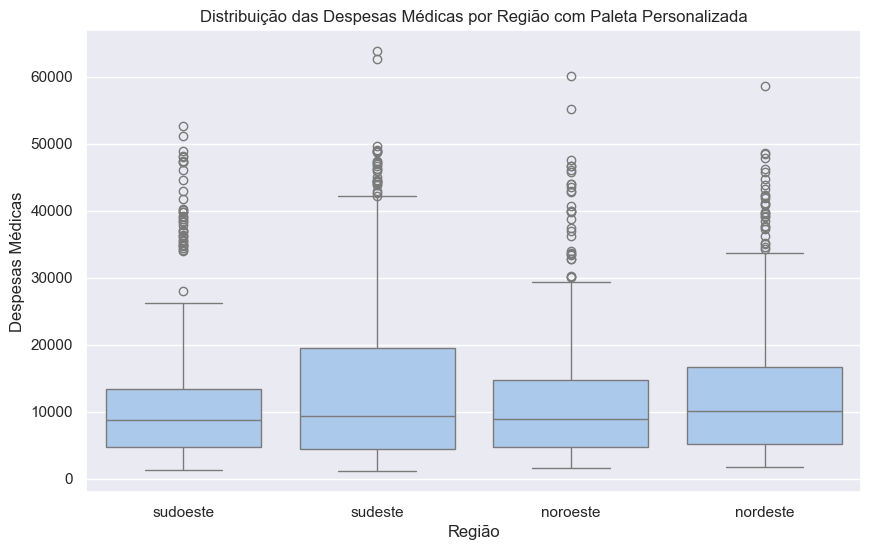

In [30]:
# Defina uma paleta de cores para os gráficos utilizando o Seaborn (ex: "pastel", "deep", "muted", entre outras), função sns.set_palette().
sns.set_palette("pastel")

# Em seguida, crie um boxplot para comparar a distribuição das despesas médicas entre as regiões, aplicando a nova paleta.
plt.figure(figsize=(10, 6))
sns.boxplot(x='regiao', y='despesas', data=df)
plt.title('Distribuição das Despesas Médicas por Região com Paleta Personalizada')
plt.xlabel('Região')
plt.ylabel('Despesas Médicas')
plt.show()

# A escolha da paleta de cores pode tornar a visualização mais agradável e facilitar a distinção entre categorias.





---



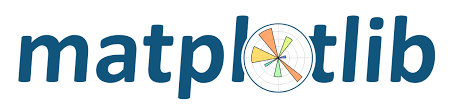

O matplotlib é uma das bibliotecas mais populares para a criação de gráficos em Python, juntamente com o Seaborn, a qual é uma "derivação" do matplotlib.
As principais funções dessa biblioteca são:



*   plt.plot(): Cria gráficos de linha.
*   plt.scatter(): Cria gráficos de dispersão.
*   plt.bar(): Cria gráficos de barras.
*   plt.hist(): Cria histogramas.
*   plt.boxplot(): Cria gráficos de caixa (boxplots).
*   plt.pie(): Cria gráficos de pizza.
*   plt.subplot(): Cria múltiplos gráficos em uma única figura.
*   plt.title(): Adiciona um título ao gráfico.
*   plt.xlabel() e plt.ylabel(): Adiciona rótulos aos eixos X e Y.
*   plt.legend(): Adiciona uma legenda ao gráfico.
*   plt.show(): Exibe o gráfico.


As principais diferenças entre o Seaborn e o Matplotlib em termos de funcionalidades, usabilidade e propósito são:

**1. Propósito e Facilidade de Uso:**

**Matplotlib:**

É uma biblioteca de gráficos de baixo nível que oferece uma grande flexibilidade para criar praticamente qualquer tipo de visualização. É poderosa, mas pode exigir mais configuração e código para criar gráficos detalhados. Como é de baixo nível, os usuários muitas vezes precisam especificar muitos detalhes para criar gráficos complexos, o que pode ser mais trabalhoso e menos intuitivo, especialmente para iniciantes.

**Seaborn:**

 É construído sobre o matplotlib e oferece uma interface de alto nível para criar gráficos estatísticos de forma mais simples e com padrões estéticos melhores. Ele é otimizado para trabalhar com dataframes do Pandas e inclui funcionalidades avançadas para visualização de relações entre variáveis.Além disso, o Seaborn é mais fácil de usar para criar gráficos estatísticos comuns, com menos código e configurações necessárias. Seus gráficos têm um estilo visual mais atraente por padrão.

**2. Estilo e Estética**

**Matplotlib:**

O estilo padrão dos gráficos em matplotlib é mais simples e básico. Embora você possa personalizar extensivamente, isso geralmente requer mais código.
A estética não é tão moderna quanto a do seaborn, a menos que você configure estilos específicos.

**Seaborn:**

Os gráficos em seaborn vêm com uma estética mais moderna e visualmente atraente por padrão. Ele aplica automaticamente estilos como cores, gridlines e tamanhos de fonte que são mais agradáveis.
Oferece vários temas e paletas de cores predefinidos, o que facilita a criação de gráficos esteticamente agradáveis.

**3. Funcionalidades Avançadas**

**Matplotlib:**

Oferece controle detalhado sobre cada aspecto do gráfico (eixos, títulos, rótulos, legendas, cores, etc.). É possível criar visualizações altamente personalizadas, como gráficos 3D, gráficos interativos, entre outros.
Ideal para gráficos que precisam de ajustes muito específicos ou visualizações complexas que não são facilmente acessíveis em bibliotecas de nível mais alto.

**Seaborn:**

Facilita a criação de gráficos estatísticos complexos, como gráficos de regressão, gráficos de distribuição, gráficos de relação categórica, entre outros, com menos código. Ademais, integra-se bem com dataframes do Pandas, facilitando a criação de gráficos com dados categóricos ou estatísticos, e inclui funcionalidades como "hue" para segmentar dados em subcategorias dentro do mesmo gráfico, o que é mais difícil de implementar no matplotlib.

**4. Flexibilidade**

**Matplotlib**:

Extremamente flexível, mas a custo de maior complexidade e configuração manual.
Pode ser usado para criar gráficos de todo tipo, incluindo gráficos não convencionais.

**Seaborn**:

Menos flexível que o matplotlib porque é construído sobre padrões predefinidos, mas é possível personalizar o comportamento de muitos gráficos utilizando as funções de matplotlib juntamente com seaborn.


**Abaixo serão apresentados alguns exemplos de como utilizar a biblioteca Matplotlib para que seja possível essa comparação na prática.**

In [21]:
# Importando a biblioteca

import matplotlib.pyplot as plt

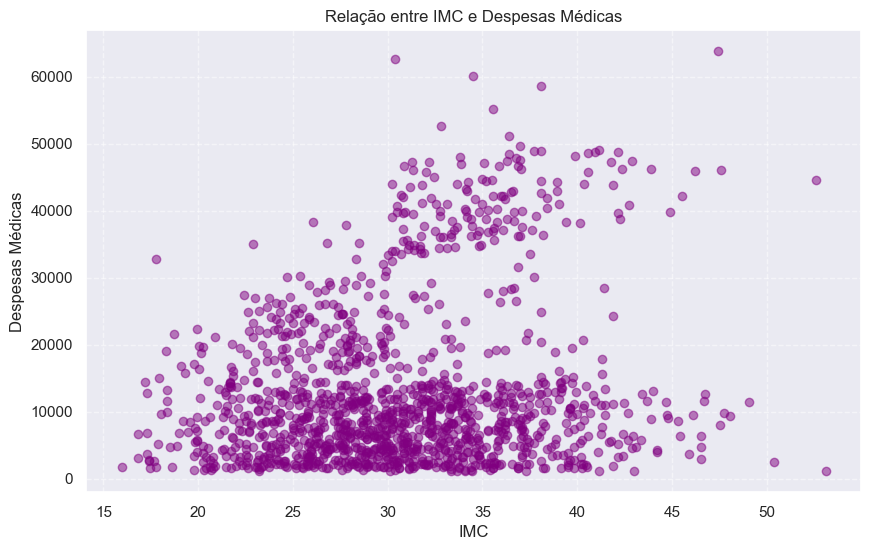

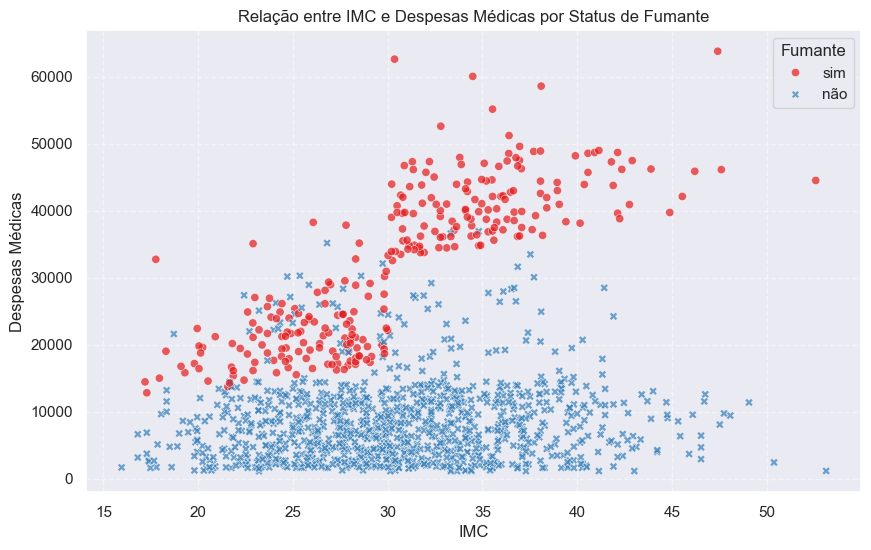

In [32]:
# Crie um gráfico de dispersão utilizando a biblioteca Matplotlib para visualizar a relação entre o IMC e as despesas médicas.
plt.figure(figsize=(10, 6))
plt.scatter(df['imc'], df['despesas'], alpha=0.5, c='purple')
plt.title('Relação entre IMC e Despesas Médicas')
plt.xlabel('IMC')
plt.ylabel('Despesas Médicas')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Personalize o gráfico definindo a cor dos pontos, o título e os rótulos dos eixos.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='imc', y='despesas', hue='fumante', style='fumante', palette='Set1', alpha=0.7)
plt.title('Relação entre IMC e Despesas Médicas por Status de Fumante')
plt.xlabel('IMC')
plt.ylabel('Despesas Médicas')
plt.legend(title='Fumante')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Esse tipo de gráfico ajuda a identificar possíveis correlações ou padrões entre duas variáveis numéricas.



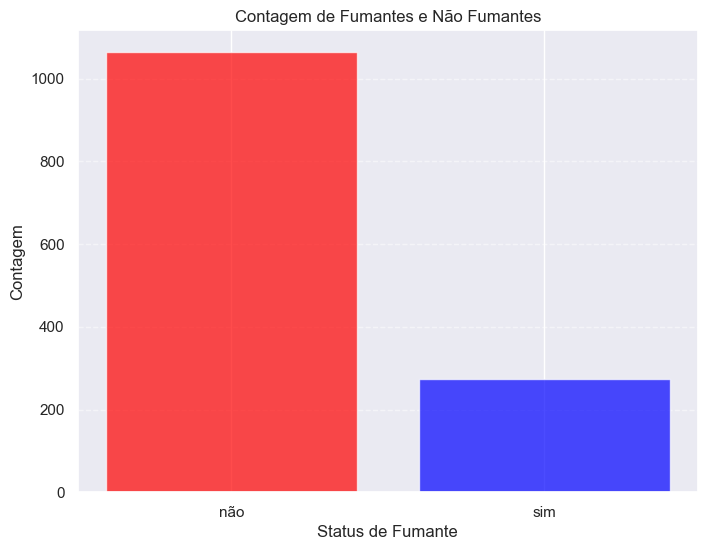

In [33]:
# Crie um gráfico de barras utilizando a biblioteca Matplotlib para mostrar a contagem de pessoas fumantes e não fumantes.
plt.figure(figsize=(8, 6))
plt.bar(df['fumante'].value_counts().index, df['fumante'].value_counts(), color=['red', 'blue'], alpha=0.7)
plt.title('Contagem de Fumantes e Não Fumantes')
plt.xlabel('Status de Fumante')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Esse tipo de gráfico é ideal para visualizar a frequência de categorias em uma variável qualitativa.



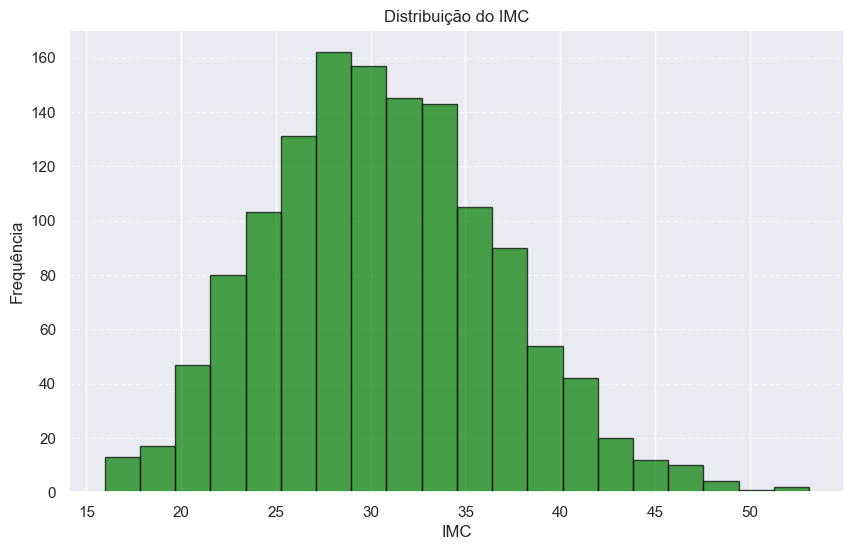

In [34]:
# Crie um histograma utilizando a biblioteca Matplotlib para visualizar a distribuição da variável IMC.
plt.figure(figsize=(10, 6))
plt.hist(df['imc'], bins=20, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribuição do IMC')
plt.xlabel('IMC')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Esse tipo de gráfico permite observar como os valores do IMC estão distribuídos, identificando concentrações, assimetrias ou possíveis outliers.



C:\Users\madso\AppData\Local\Temp\ipykernel_1976\2209508374.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_grouped['despesas'], labels=df_grouped['regiao'])


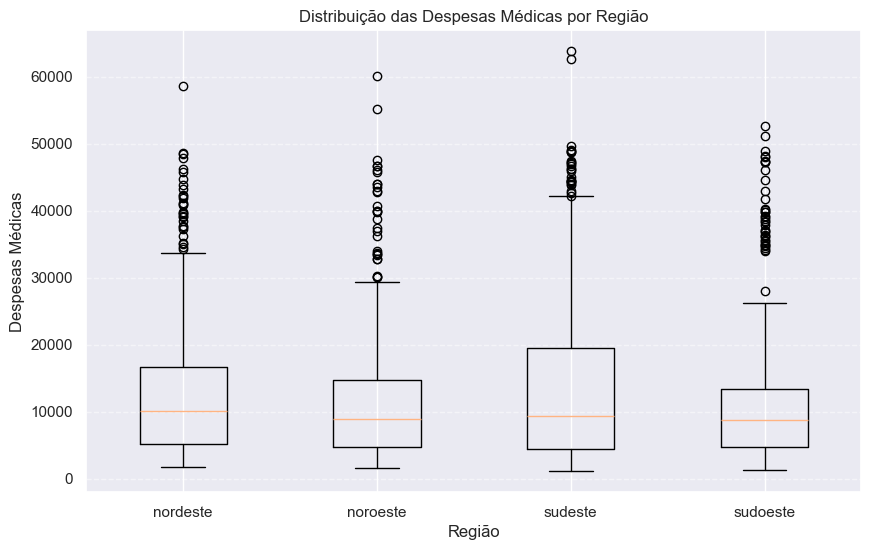

In [ ]:
# Agrupe os dados de despesas por região para preparar os dados que serão usados no boxplot.
# Agrupando os dados por região
df_grouped = df.groupby('regiao')['despesas'].apply(list).reset_index()
# Em seguida, utilize a função boxplot da biblioteca Matplotlib para visualizar a distribuição das despesas em cada região.
plt.figure(figsize=(10, 6))
plt.boxplot(df_grouped['despesas'], labels=df_grouped['regiao'])
plt.title('Distribuição das Despesas Médicas por Região')
plt.xlabel('Região')
plt.ylabel('Despesas Médicas')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# O boxplot permite identificar a mediana, a dispersão e possíveis outliers nos dados de cada grupo.
# Adicione rótulos nos eixos e um título para tornar a visualização mais clara e informativa.




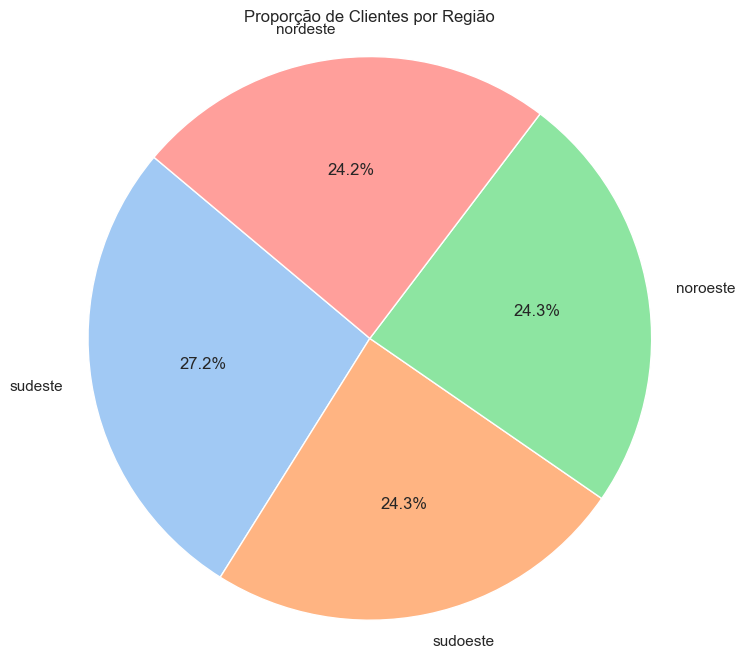

In [36]:
# Crie um gráfico de pizza para visualizar a proporção de clientes em cada região.
plt.figure(figsize=(8, 8))
plt.pie(df['regiao'].value_counts(), labels=df['regiao'].value_counts().index, autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=140)
plt.title('Proporção de Clientes por Região')
plt.axis('equal')  # Para garantir que o gráfico seja um círculo
plt.show()

# Utilize o método value_counts() para contar a quantidade de ocorrências por categoria e, em seguida, plote com o tipo 'pie'.


# Adicione porcentagens no gráfico com o parâmetro autopct e personalize as cores para melhorar a apresentação visual.
# Remova o rótulo do eixo Y para deixar a visualização mais limpa.



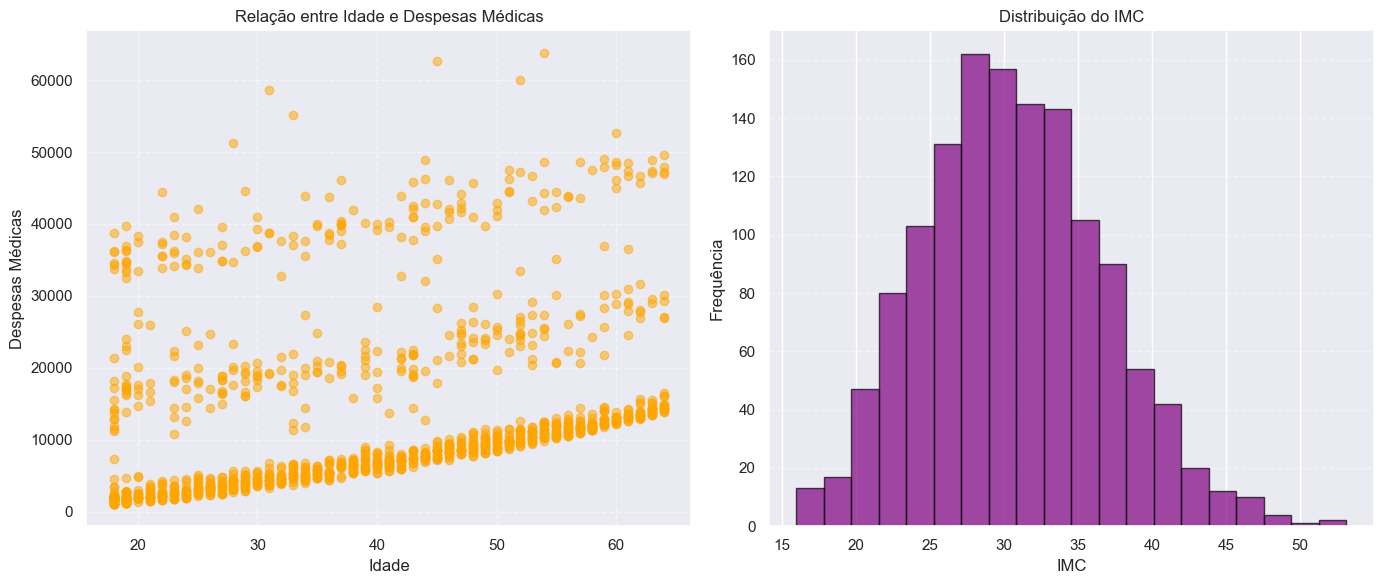

In [37]:
# Crie uma figura com dois gráficos lado a lado utilizando subplots do Matplotlib.
# No primeiro gráfico, faça um gráfico de dispersão para analisar a relação entre idade e despesas médicas.
# No segundo, plote um histograma para visualizar a distribuição dos valores de IMC.
# Ajuste o tamanho da figura e use o comando tight_layout() para evitar sobreposição entre os elementos gráficos.
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].scatter(df['idade'], df['despesas'], alpha=0.5, c='orange')
axs[0].set_title('Relação entre Idade e Despesas Médicas')
axs[0].set_xlabel('Idade')
axs[0].set_ylabel('Despesas Médicas')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[1].hist(df['imc'], bins=20, color='purple', alpha=0.7, edgecolor='black')
axs[1].set_title('Distribuição do IMC')
axs[1].set_xlabel('IMC')
axs[1].set_ylabel('Frequência')
axs[1].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

